In [1]:
import os
import random
from tqdm import tqdm
from samplers import PendulumSampler
from curriculum import Curriculum
from random import randint
import uuid
import ipdb

from quinine import QuinineArgumentParser
import torch
import yaml
from schema import schema
from models import build_model
import math
import random
import numpy as np
import torch
import pickle

from workCon import checking  
from workCon_ebonye import checking as checking_ebonye
import matplotlib.pyplot as plt
from scipy.linalg import solve_continuous_are
%load_ext autoreload
%autoreload 2

/home/esmith/.conda/envs/icl_ebonye_pendulum/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def simulate_inverted_pendulum_rk4(X0, total_time, dt=0.01, K=None,  mass = 1, length=1):
    """
    Simulates the dynamics of an inverted pendulum using the Runge-Kutta 4th-order method (RK4),
    with an optional state-feedback control law (LQR) applied.

    Args:
        X0 (list or np.ndarray): Initial state of the pendulum [theta, thetadot].
            - theta (float): Initial angular position in radians.
            - thetadot (float): Initial angular velocity.
        total_time (float): Total duration of the simulation in seconds.
        dt (float, optional): Time step for the simulation. Defaults to 0.01.
        K (np.ndarray, optional): The LQR gain matrix used for state-feedback control. 
        mass (float, optional): Mass of the pendulum Defaults to 1.
        length (float, optional): Length of the pendulum. Defaults to 1.

    Raises:
        ValueError: If the control gain matrix K is not provided.

    Returns:
        tuple: A tuple containing:
            - T (np.ndarray): Array of time steps during the simulation.
            - theta (np.ndarray): Array of angular positions over time.
            - thetadot (np.ndarray): Array of angular velocities over time.
            - tau (np.ndarray): It's the (u) used for stabilizing.

    Notes:
        - The control input u is computed using the state-feedback control law: u = -K(x - x_d).
        - The desired state x_d is [theta_d, thdot_d], which is set to [0, 0] by default.
        - The system dynamics are defined as:
          - velocity: d(theta)/dt = thetadot     
          - acceleration: d(thetadot)/dt = (-b * thetadot + m * g * l * sin(theta) + u) / (m * l^2)
        - RK4 is used to find next states.
    """
    params = {'m': mass, 'l': length, 'b': 0.5, 'g': 9.81}
    K = np.squeeze(K)
 
    if K is None:
        raise ValueError("no K LQR.")

    T = np.arange(0, total_time + dt, dt)
    n_steps = len(T)

    x = np.array(X0, dtype=float)
    theta = np.zeros(n_steps)
    thetadot = np.zeros(n_steps)
    tau = np.zeros(n_steps)

    theta[0] = x[0]
    thetadot[0] = x[1]

    theta_d = 0.0
    # theta_d = np.pi
    thdot_d = 0.0

    def f(x, u):
        m, l, b, g = params["m"], params["l"], params["b"], params["g"]
        theta = x[0]
        thetadot = x[1]
        dtheta = thetadot
        dthetadot = (-b * thetadot + m * g * l * np.sin(theta) + u) / (m * l**2)
        return np.array([dtheta, dthetadot])

    for i in range(n_steps - 1):
        u = -K @ (x - np.array([theta_d, thdot_d]))
        # u = 0
        tau[i] = u

        # RK4
        k1 = f(x, u)
        k2 = f(x + 0.5 * dt * k1, u)
        k3 = f(x + 0.5 * dt * k2, u)
        k4 = f(x + dt * k3, u)
        x = x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

        theta[i + 1] = x[0]
        thetadot[i + 1] = x[1]

    u = -K @ (x - np.array([theta_d, thdot_d]))
    # u = 0
    tau[-1] = u

    return T, theta, thetadot, tau

In [3]:
def run_lqr_and_simulate(X0, total_time, dt=0.01, mass = 1, length = 1, check = False):
    """
    Computes the LQR gain matrix (K) for an inverted pendulum system and simulates its dynamics 
    using the Runge-Kutta method (RK4). Optionally, the function can return only the LQR gain matrix 
    without running the simulation (was using it for debugging).

    Args:
        X0 (list or np.ndarray): The initial state of the pendulum system [theta, thetadot], where:
            - theta (float): Initial angular position (in radians).
            - thetadot (float): Initial angular velocity.
        total_time (float): Total simulation time (in seconds).
        dt (float, optional): Time step for the simulation. Defaults to 0.01.
        mass (float, optional): The mass of the pendulum. Defaults to 1.
        length (float, optional): The length of the pendulum. Defaults to 1.
        check (bool, optional): If True, return the LQR gain matrix (K) without running the simulation. Defaults to False.

    Returns:
        If `check` is True:
            np.ndarray: The LQR gain matrix (K), a 1x2 row vector used for the state feedback control.

        If `check` is False:
            tuple: A tuple containing:
                - T (np.ndarray): Array of time steps during the simulation.
                - theta (np.ndarray): Array of angular positions over time.
                - thetadot (np.ndarray): Array of angular velocities over time.
                - tau (np.ndarray): Array of u's that were used.
                - K (np.ndarray): The LQR gain matrix (K).
    """
    m = mass
    l = length
    b = 0.5
    g = 9.81

    A = np.array([[0, 1],
                  [g/l, -b/(m*l**2)]])
    B = np.array([[0],
                  [1/(m*l**2)]])

    
    # Q = np.eye(2)    #  2x2 identity matrix for Q (just keep it constant but can tune)
    Q = np.diag([1, 1]) 
    R = np.array([[1]])  # # scalar 1 for R (can change but just keep constant for simplicity)
    #### 2/24/2025 penalize control input ^
    
    K = compute_lqr_gain(A, B, Q, R)
    if check == True:
        return K

    T, theta, thetadot, tau = simulate_inverted_pendulum_rk4(X0, total_time, dt, K=K, mass = mass, length=length)
    # T, theta, thetadot, tau = simulate_inverted_pendulum_rk4(X0, total_time, dt, K=K, mass = 0.4, length=0.4)
    return T, theta, thetadot, tau, K


def compute_lqr_gain(A, B, Q, R):
    """
    Compute the Linear-Quadratic Regulator (LQR) gain matrix K for the continuous-time system:
    x_dot = A x + B u, minimizing the cost function:
        J = ∫ (x^T Q x + u^T R u) dt

    Args:
        A (np.ndarray): The state-space matrix representing the system dynamics.
        B (np.ndarray): The input matrix representing how control inputs affect the system.
        Q (np.ndarray): The state cost matrix, defining the penalty on the states.
        R (np.ndarray): The control input cost matrix, defining the penalty on the control inputs.

    Returns:
        np.ndarray: The LQR gain matrix K, which determines the optimal control law u = -Kx
                    to minimize the cost function J.
    """

    X = solve_continuous_are(A, B, Q, R)
    K = np.linalg.inv(R) @ (B.T @ X)
    return K


In [4]:
X0 = [np.pi, 0]  # Initial state: [theta, thetadot]
total_time = 4  # Total simulation time in seconds
dt = 0.05  # Time step for the simulation
mass = 2
length = 1
T, theta, thetadot, control_values, k_values = run_lqr_and_simulate(X0, total_time, dt, mass = mass, length=length)

print(f'Control values: {control_values}')
print(f'[theta, thetadot]: {np.stack([theta, thetadot], axis=1)}')

Control values: [-1.23356105e+02 -8.34704172e+01 -5.19355216e+01 -2.85884031e+01
 -1.25457087e+01 -2.42644852e+00  3.32726346e+00  6.14621204e+00
  7.15821213e+00  7.15358563e+00  6.63723184e+00  5.90789237e+00
  5.13005510e+00  4.38700239e+00  3.71567807e+00  3.12797598e+00
  2.62307940e+00  2.19432178e+00  1.83285119e+00  1.52949469e+00
  1.27563844e+00  1.06358564e+00  8.86647856e-01  7.39108068e-01
  6.16128620e-01  5.13641432e-01  4.28238884e-01  3.57073503e-01
  2.97769453e-01  2.48346221e-01  2.07153730e-01  1.72817617e-01
  1.44193342e-01  1.20327804e-01  1.00427323e-01  8.38309365e-02
  6.99881762e-02  5.84405536e-02  4.88061555e-02  4.07668210e-02
  3.40574712e-02  2.84572273e-02  2.37820192e-02  1.98784331e-02
  1.66185898e-02  1.38958813e-02  1.16214209e-02  9.72108782e-03
  8.13306576e-03  6.80579322e-03  5.69625625e-03  4.76856631e-03
  3.99277550e-03  3.34388948e-03  2.80104491e-03  2.34682399e-03
  1.96668309e-03  1.64847653e-03  1.38205952e-03  1.15895711e-03
  9.72088

In [5]:
# X0 = [np.pi, 1]
# # print(0.3 * 180 / math.pi)
# # print(X0)
# n_points = 3
# mass = 2
# length = 2
# T, theta, thetadot, control_values, k_values = checking(X0, n_points, method='rk4', dt=0.01,mass = mass,length = length)
# T_ebonye, theta_ebonye, thetadot_ebonye, control_values_ebonye = checking_ebonye(X0, n_points, method='rk4', dt=0.01,mass = mass,length = length)

# print("k values: ", k_values)

In [6]:
# ##### Generate pendulums
# num_pendulums = 100
# masses = np.random.uniform(2.1, 5, num_pendulums)
# lengths = np.random.uniform(2.1, 5, num_pendulums)
# X0 = [np.pi, 1]

# theta_pends = []
# thetadot_pends = []
# control_pends = []

# for i in range(num_pendulums):
#     mass = masses[i]
#     length = lengths[i]
#     T, theta, thetadot, control_values, k_values = checking(X0, n_points, method='rk4', dt=0.01,mass = mass,length = length)
#     theta_pends.append(theta)
#     thetadot_pends.append(thetadot)
#     control_pends.append(control_values)
#     # print(f"Pendulum {i+1} done.")




In [7]:
# #### Plotting
# fig, ax = plt.subplots(1, 2, figsize=(20, 10))
# for i in range(num_pendulums):
#     ax[0].plot(T, theta_pends[i], label=f"Pendulum {i+1}")
#     ax[1].plot(T, thetadot_pends[i], label=f"Pendulum {i+1}")
# ax[0].set_title("Theta vs Time")
# ax[0].set_xlabel("Time")
# ax[0].set_ylabel("Theta")
# # ax[0].legend()
# ax[1].set_title("ThetaDot vs Time")
# ax[1].set_xlabel("Time")   
# ax[1].set_ylabel("ThetaDot")
# # ax[1].legend()

In [8]:
# # plt.figure()
# # plt.scatter(theta,thetadot)
# # plt.xlabel('theta')
# # plt.ylabel('thetadot')
# # plt.title('Phase plot: LQR about 0')
# # plt.show()

# # plt.figure()
# # plt.scatter(theta_ebonye,thetadot_ebonye)
# # plt.xlabel('theta')
# # plt.ylabel('thetadot')
# # plt.title('Phase plot: LQR about current state')
# # plt.show()
# fig, ax = plt.subplots(2, 1, figsize=(9, 9))
# ax[0].scatter(theta,thetadot)
# ax[0].set_xlabel('theta')
# ax[0].set_ylabel('thetadot')
# ax[0].set_title('Phase plot: LQR about 0') 
# ax[1].scatter(theta_ebonye,thetadot_ebonye)
# ax[1].set_xlabel('theta')
# ax[1].set_ylabel('thetadot')
# ax[1].set_title('Phase plot: LQR about current state')
# plt.show()

In [9]:
# # plt.figure()
# # plt.scatter(T,control_values)
# # plt.xlabel('time')
# # plt.ylabel('control')
# # plt.title('Control plot: LQR about 0')
# # plt.show()

# # plt.figure()
# # plt.scatter(T_ebonye,control_values_ebonye)
# # plt.xlabel('time')
# # plt.ylabel('control')  
# # plt.title('Control plot: LQR about current state')
# # plt.show()

# fig, ax = plt.subplots(2, 1, figsize=(9, 9))
# ax[0].scatter(T, control_values, label='LQR about 0')
# ax[0].set_xlabel('time')
# ax[0].set_ylabel('control')
# ax[0].set_title('Control plot: LQR about 0')
# ax[0].legend()
# ax[1].scatter(T_ebonye, control_values_ebonye, label='LQR about current state')
# ax[1].set_xlabel('time')
# ax[1].set_ylabel('control')
# ax[1].set_title('Control plot: LQR about current state')
# ax[1].legend()
# plt.show()

In [10]:
# fig, ax = plt.subplots(1, 2, figsize=(10, 5))
# ax[0].plot(T, theta)
# ax[0].set_xlabel('Time')
# ax[0].set_ylabel('Theta')
# ax[0].set_title('Theta vs Time: LQR about 0')
# ax[1].plot(T, thetadot)
# ax[1].set_xlabel('Time')
# ax[1].set_ylabel('Theta_dot')
# ax[1].set_title('Theta_dot vs Time: LQR about 0')
# plt.show()

# fig, ax = plt.subplots(1, 2, figsize=(10, 5))
# ax[0].plot(T_ebonye, theta_ebonye)
# ax[0].set_xlabel('Time')
# ax[0].set_ylabel('Theta')
# ax[0].set_title('Theta vs Time: LQR about current state')        
# ax[1].plot(T_ebonye, thetadot_ebonye)
# ax[1].set_xlabel('Time')
# ax[1].set_ylabel('Theta_dot')
# ax[1].set_title('Theta_dot vs Time: LQR about current state')
# plt.show()

In [11]:
# # Using control of one pendulum on a different pendulum
# print(f"True mass: {mass}, True length: {length}")
# mass2 = mass
# length2 = length
# params = {'m': mass2, 'l': length2, 'b': 0.5, 'g': 9.81}
# print(f"Using mass: {mass2}, Using length: {length2}")
# steps = int(n_points/0.01)
# controls = control_values

# def f(x, u):
#     m, l, b, g = params["m"], params["l"], params["b"], params["g"]
#     theta = x[0]
#     thetadot = x[1]
#     dtheta = thetadot
#     dthetadot = (-b * thetadot + m * g * l * np.sin(theta) + u) / (m * l**2)
#     return np.array([dtheta, dthetadot])

# traj = []
# traj.append([np.pi, 1])
# for i in range(steps):
#     x = traj[-1]
#     u = controls[i]
#     # rk4
#     k1 = f(x, u)
#     k2 = f(x + 0.5 * 0.01 * k1, u)
#     k3 = f(x + 0.5 * 0.01 * k2, u)
#     k4 = f(x + 0.01 * k3, u)
#     x = x + 0.01 / 6 * (k1 + 2*k2 + 2*k3 + k4)
#     traj.append(x)
# traj = np.array(traj)
# # print(traj)



In [12]:
# theta3 = traj[:,0]
# thetadot3 = traj[:,1]
# T3 = np.linspace(0, steps*0.01, steps+1)
# plt.figure()
# plt.scatter(theta3,thetadot3)
# plt.xlabel('theta')
# plt.ylabel('thetadot')
# plt.title(f'Phase plot: LQR about 0, True mass: {mass}, True length: {length}, Using mass: {mass2}, Using length: {length2}')
# plt.show()

In [80]:
import numpy as np
from scipy.linalg import solve_continuous_are
from numba import njit
from scipy.signal import place_poles

def batch_lqr_gains(lambda1, lambda2, Q, R):
    """
    Computes LQR gains for multiple systems in a batch.
    """
    n = len(lambda1)
    K_all = np.zeros((n, 1, 2))  # shape (systems, 1, 2)
    for i in range(n):
        l1, l2 = lambda1[i], lambda2[i]
        A = np.array([[l1, 0],
                      [0, l2]])
        # A = np.diag([l1, l2])

        print(f"A: {A}")
        
        B = np.array([[1.0],
                      [1.0]])
        X = solve_continuous_are(A, B, Q, R)
        K = np.linalg.inv(R) @ (B.T @ X)
        # desired_poles = np.array([-1, -1.1])
        desired_poles = np.array([-5, -6])
        place_obj = place_poles(A, B, desired_poles)
        K = place_obj.gain_matrix
        K = np.reshape(K, (1, 2))
        print(f"K shape: {K.shape}")
        print(f"K: {K}")
        print(f"A-BK: {A - B @ K}")
        print(f"eignvalues: {np.linalg.eig(A - B @ K)}")
        K_all[i] = K
    return K_all  # shape (n, 1, 2)

# @njit
# def simulate_batch(X0_list, K_all, dt, n_steps):
def simulate_batch(X0_list, K_all, lambda1, lambda2, dt, n_steps):
    """
    Vectorized RK4 simulation using LQR feedback for multiple systems.
    """
    X0_list = np.array(X0_list)
    # num_systems = X0_list.shape[0]
    num_systems = len(K_all)
    x1_all = np.zeros((num_systems, n_steps))
    x2_all = np.zeros((num_systems, n_steps))
    tau_all = np.zeros((num_systems, n_steps))

    for i in range(num_systems):
        x = X0_list

        K = K_all[i]
        print(f"x: {x}")
        x1_all[i, 0] = x[0]
        x2_all[i, 0] = x[1]
        # mass, length = masses[i], lengths[i]
        l1, l2 = lambda1[i], lambda2[i]

        for t in range(n_steps - 1):
            if t < 30:
                u = [0]
            else:
                u = - K @ (x - np.array([0.0, 0.0]))
            tau_all[i, t] = u[0]
            # x = rk4_step(x, u[0], dt)
            x = rk4_step(x, u[0], dt, l1, l2)
            x1_all[i, t + 1] = x[0]
            x2_all[i, t + 1] = x[1]

    return x1_all, x2_all, tau_all

# @njit
def rk4_step(x, u, dt, l1, l2):
    """
    RK4 integrator for a single system step.
    """
    def f(x, u):
        A = np.diag([l1, l2])
        B = np.array([[1.0],
                      [1.0]])
        
        return A @ x + B.flatten() * u

    k1 = f(x, u)
    k2 = f(x + 0.5 * dt * k1, u)
    k3 = f(x + 0.5 * dt * k2, u)
    k4 = f(x + dt * k3, u)
    return x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

def run_all_simulations(X0_list, total_time, dt, lambda1, lambda2):
    n_steps = int(total_time / dt) + 1
    Q = np.eye(2)
    R = np.array([[1]])
    K_all = batch_lqr_gains(lambda1, lambda2, Q, R)
    x1, x2, tau = simulate_batch(X0_list, K_all, lambda1, lambda2, dt, n_steps) 
    T = np.linspace(0, total_time, n_steps)
    return T, x1, x2, tau


def checking(X0, total_time, lambda1, lambda2, method='rk4', dt=0.01):
    """
    Checks the simulation of inverted pendulum systems using either RK4 or Euler methods.
    
    Args:
        X0 (list or np.ndarray): Initial state of the pendulum [theta, thetadot].
        total_time (float): Total duration of the simulation in seconds.
        lambda1 (float): first eigenvalue for the system.
        lambda2 (float): second eigenvalue for the system.
        method (str, optional): Method to use for simulation ('rk4' or 'euler'). Defaults to 'rk4'.
        dt (float, optional): Time step for the simulation. Defaults to 0.01.
    
    Returns:
        T, theta_all, thetadot_all, tau_all: Simulation results for each system.
    """
    if method == 'rk4':
        # T, theta_all, thetadot_all, tau_all = vectorized_simulation(X0, total_time, dt, masses, lengths)
        # T, theta_all, thetadot_all, tau_all = run_all_simulations(X0, total_time, dt, lambda1, lambda2)
        T, x1_all, x2_all, tau_all = run_all_simulations(X0, total_time, dt, lambda1, lambda2)
    else:
        raise ValueError("Invalid method. Choose 'rk4'.")
    
    # return T, theta_all, thetadot_all, tau_all
    return T, x1_all, x2_all, tau_all



In [83]:
# Example usage
# X0 = [-1, 1]
X0 = np.random.uniform(-1, 1, 2)
total_time = 2.5
dt = 0.01
lambda1 = np.random.uniform(0.1, 1, 1)
lambda2 = np.random.uniform(1, 1.5, 1)

T, x1_all, x2_all, tau_all = checking(X0, total_time, lambda1=lambda1, lambda2=lambda2, method='rk4', dt=dt)
# print(f"Control values: {tau_all}")
print(f"X0: {X0}")
print(f"lambda1: {lambda1}")
print(f"lambda2: {lambda2}")
print(f"x1_all: {x1_all}")
print(f"x2_all: {x2_all}")

def has_converged(x1, x2, threshold=1e-3, last_n=20):
    norms = np.linalg.norm(np.vstack((x1, x2)), axis=0)
    return np.all(norms[-last_n:] < threshold)

# Check convergence
if has_converged(x1_all[0], x2_all[0]):
    print("The system has converged.")
else:
    print("The system has not converged.")


A: [[0.64469502 0.        ]
 [0.         1.40626955]]
K shape: (1, 2)
K: [[-49.24964747  62.30061204]]
A-BK: [[ 49.89434249 -62.30061204]
 [ 49.24964747 -60.89434249]]
eignvalues: EigResult(eigenvalues=array([-5., -6.]), eigenvectors=array([[0.75029645, 0.74434005],
       [0.66110153, 0.66780079]]))
x: [-0.78369227 -0.97802579]
X0: [-0.78369227 -0.97802579]
lambda1: [0.64469502]
lambda2: [1.40626955]
x1_all: [[-7.83692265e-01 -7.88761012e-01 -7.93862542e-01 -7.98997067e-01
  -8.04164802e-01 -8.09365960e-01 -8.14600758e-01 -8.19869414e-01
  -8.25172146e-01 -8.30509175e-01 -8.35880723e-01 -8.41287012e-01
  -8.46728269e-01 -8.52204718e-01 -8.57716588e-01 -8.63264107e-01
  -8.68847506e-01 -8.74467018e-01 -8.80122875e-01 -8.85815313e-01
  -8.91544569e-01 -8.97310880e-01 -9.03114486e-01 -9.08955629e-01
  -9.14834550e-01 -9.20751496e-01 -9.26706711e-01 -9.32700443e-01
  -9.38732941e-01 -9.44804456e-01 -9.50915240e-01 -4.94797962e-01
  -8.71983785e-02  2.75968500e-01  5.98474383e-01  8.838006

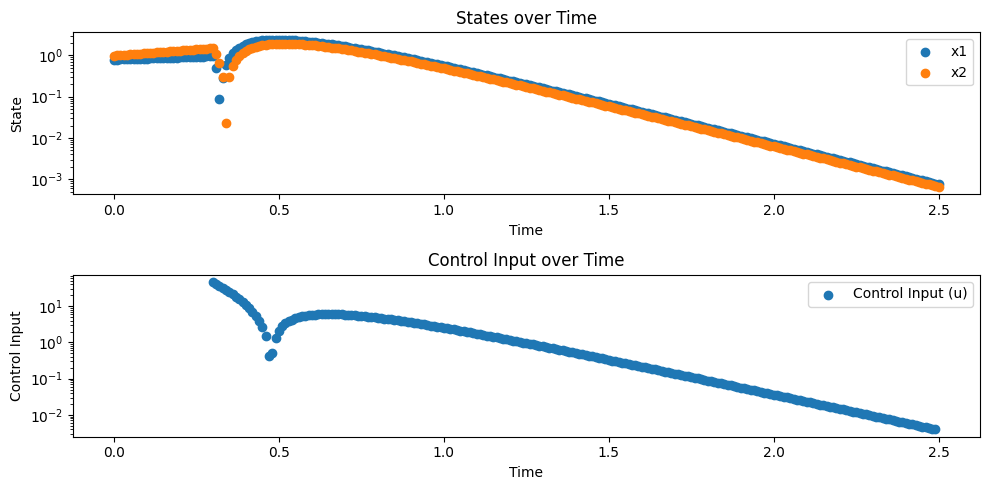

In [84]:
# plotting
plt.figure(figsize=(10, 5))
plt.subplot(2, 1, 1)
# print(f"x1_all shape: {x1_all.shape}")
plt.scatter(T, np.abs(x1_all[0]), label='x1')
plt.scatter(T, np.abs(x2_all[0]), label='x2')
plt.yscale('log')
plt.xlabel('Time')
plt.ylabel('State')
plt.title('States over Time')
plt.legend()
plt.subplot(2, 1, 2)
plt.scatter(T, np.abs(tau_all[0]), label='Control Input (u)')
plt.xlabel('Time')
plt.ylabel('Control Input')
plt.yscale('log')
plt.title('Control Input over Time')
plt.legend()
plt.tight_layout()
plt.show()